In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder


In [ ]:
df = pd.read_csv("sales.csv")

In [ ]:
print(df.head())

   customer_id signup_date country  ...  gender loyalty_tier acquisition_channel
0            1  08-04-2021      BR  ...    Male       Bronze            Referral
1            2  28-04-2023      IN  ...  Female       Silver             Organic
2            3  18-12-2022      UK  ...  Female       Silver             Organic
3            4  26-04-2022      US  ...    Male       Silver         Paid Search
4            5  20-04-2022      IN  ...    Male       Silver             Organic

[5 rows x 7 columns]


In [ ]:
encoder = LabelEncoder()
df['loyalty_encoded'] = encoder.fit_transform(df['loyalty_tier'])

In [ ]:
print(df[['loyalty_tier']].head())

   loyalty_tier
0             0
1             3
2             3
3             3
4             3


In [ ]:
x = df[['age','loyalty_encoded']]

In [ ]:
model = KMeans(n_clusters=3, random_state=42)

In [ ]:
model.fit(x)

KMeans(n_clusters=3, random_state=42)

In [ ]:
df['clusters'] = model.labels_
print("Clustered Customers")

Clustered Customers


In [ ]:
print(model.cluster_centers_)

[[34.58076133  0.92589974]
 [46.76750959  0.91885965]
 [23.18103549  0.933002  ]]


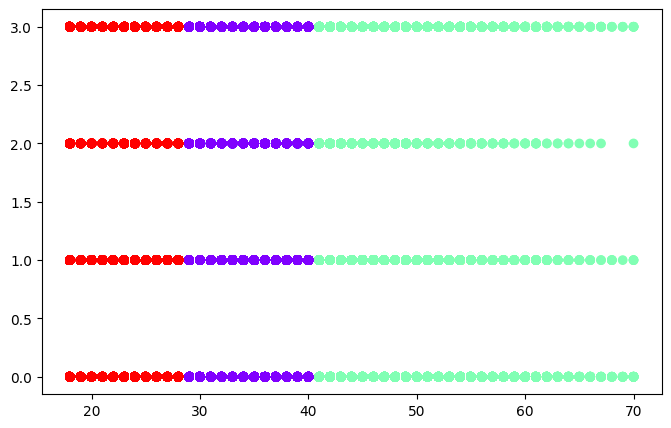

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['loyalty_encoded'], c = df['clusters'], cmap= 'rainbow')

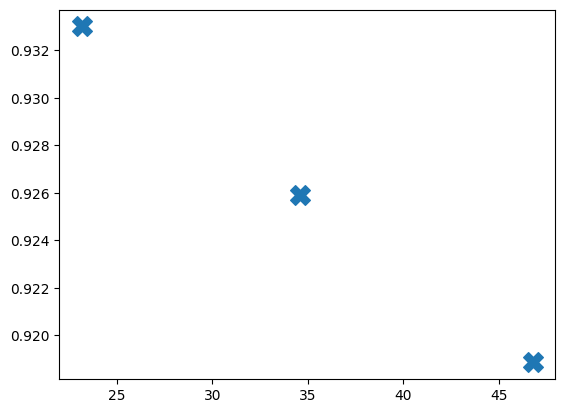

In [ ]:
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=200, marker='X')

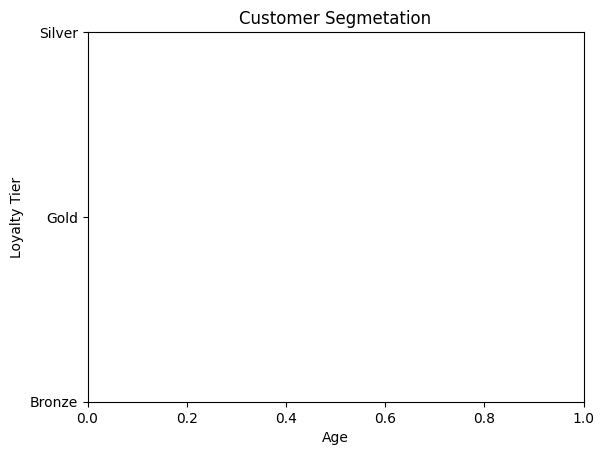

In [ ]:
plt.xlabel("Age")
plt.ylabel("Loyalty Tier")
plt.title("Customer Segmetation")
plt.yticks([0,1,2], ['Bronze','Gold','Silver'])
plt.show()